# IMPORT

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from xgboost import XGBClassifier
from tensorflow.keras.models import load_model
from sklearn.feature_selection import RFE
from sklearn.tree import plot_tree
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

# DATASET

In [41]:
nps_dataset = pd.read_csv('datasetNPS/PENTION_EI_Complete.csv', sep=',', header=0)

print(f'The dataset has {nps_dataset.shape[0]} instances and {nps_dataset.shape[1]} features.')
nps_dataset.head()

The dataset has 3342 instances and 602 features.


,Name,1,2,3,4,5,6,7,8,9,...,592,593,594,595,596,597,598,599,600,label
0,1-(1-Phenylcyclohexyl)azepane,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,1-(1-Phenylcyclohexyl)azetidine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,"1-(1,3-Diphenylpropan-2-yl)pyrrolidine",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,1-(2-Chloro-3-fluorophenyl)piperazine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,1-[(2-Chlorophenyl)(methylimino)methyl]cyclope...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6


In [42]:
nps_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3342 entries, 0 to 3341
Columns: 602 entries, Name to label
dtypes: float64(600), int64(1), object(1)
memory usage: 15.3+ MB


In [43]:
nps_dataset.describe()

,1,2,3,4,5,6,7,8,9,10,...,592,593,594,595,596,597,598,599,600,label
count,3342.0,3342.0,3342.0,3342.0,3342.0,3342.0,3342.0,3342.0,3342.0,3342.0,...,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.0,3342.000000,3342.000000,3342.000000,3342.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002101,0.005987,0.001795,0.000302,0.000305,0.0,0.000299,0.000604,0.000299,3.605027
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.066973,0.345961,0.103788,0.017299,0.017300,0.0,0.017298,0.024461,0.017298,2.399905
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,5.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,6.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.000000,20.000000,6.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,6.000000


In [44]:
print(nps_dataset.isnull().sum(axis=1))

0       0
1       0
2       0
3       0
4       0
       ..
3337    0
3338    0
3339    0
3340    0
3341    0
Length: 3342, dtype: int64


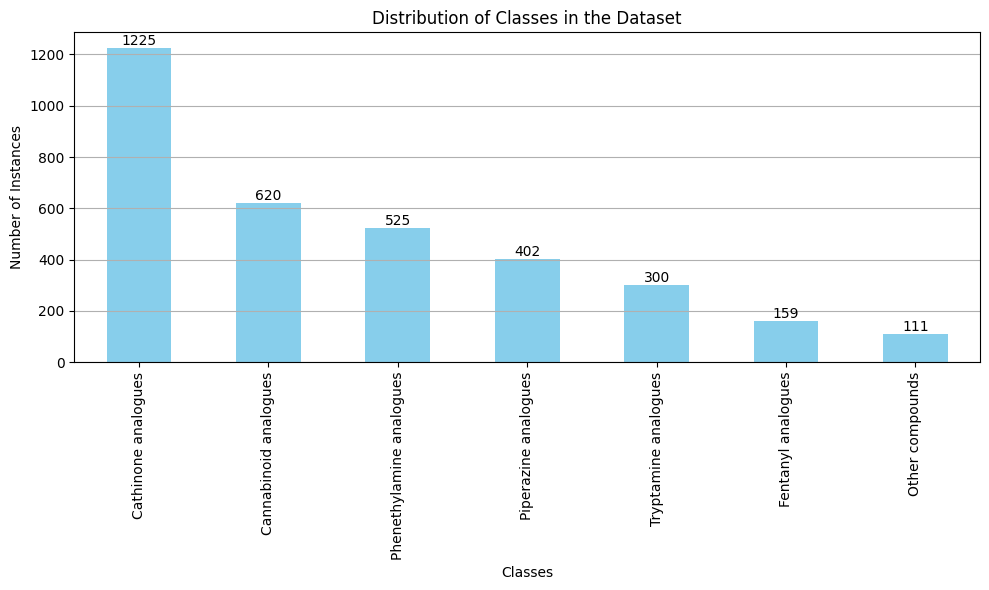

In [45]:
classes = ['Cathinone analogues', 'Cannabinoid analogues',
           'Phenethylamine analogues', 'Piperazine analogues',
           'Tryptamine analogues', 'Fentanyl analogues', 'Other compounds']

distributions = nps_dataset['label'].value_counts()

legends = {
  0: 'Cathinone analogues',
  1: 'Cannabinoid analogues',
  2: 'Phenethylamine analogues',
  3: 'Piperazine analogues',
  4: 'Tryptamine analogues',
  5: 'Fentanyl analogues',
  6: 'Other compounds'
}

plt.figure(figsize=(10, 6))
ax = distributions.plot(kind='bar', color='skyblue')
plt.title('Distribution of Classes in the Dataset')
plt.xlabel('Classes')
plt.ylabel('Number of Instances')
plt.xticks(ticks=range(len(classes)), labels=[legends[i] for i in range(len(classes))], rotation=90)
plt.grid(axis='y')
plt.tight_layout()

for p in ax.patches:
  ax.annotate(str(int(p.get_height())), 
        (p.get_x() + p.get_width() / 2, p.get_height()), 
        ha='center', va='bottom', fontsize=10)

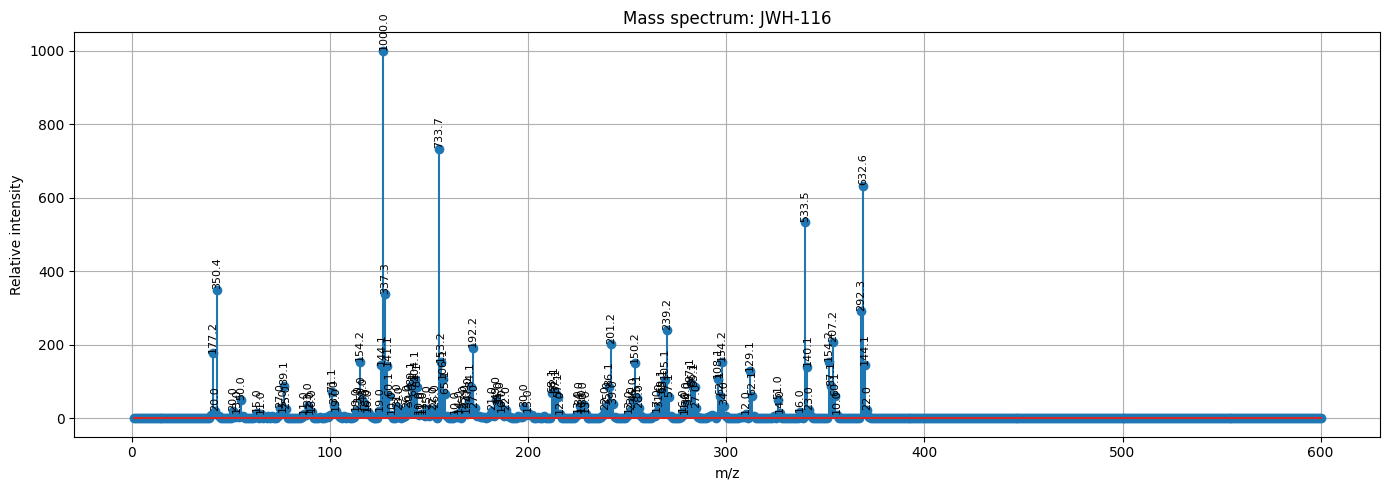

In [46]:
nome = "JWH-116"
riga = nps_dataset[nps_dataset.iloc[:, 0] == nome].iloc[0]
spettro = riga[1:-1].astype(float).values 
mz = list(range(1, 601))
plt.figure(figsize=(14, 5))
(markerline, stemlines, baseline) = plt.stem(mz, spettro)
plt.xlabel("m/z")
plt.ylabel("Relative intensity")
plt.title(f"Mass spectrum: {nome}")
plt.grid(True)

soglia = 10.0
for mzi, intensita in zip(mz, spettro):
    if intensita > soglia:
        plt.text(mzi, intensita + 1, f"{intensita:.1f}", ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

Base Peak Mass: Mass-to-charge ratio (m/z) of the peak with the greatest intensity (i.e., “base peak”) 

Base Peak Mass Proximity: m/z difference between base peak and the peak with the nearest m/z value 

Maximum Mass: m/z of the peak with the greatest mass 

Maximum Mass Proximity: m/z difference between maximum-mass peak and the peak with the nearest m/z value 

Number of Peaks: Total number of reported peaks in the spectrum 

Intensity Mean: Mean of all peaks’ intensity values 

Intensity Standard Deviation Standard: deviation of all peaks’ intensity values 

Intensity Density: Maximum intensity divided by number of peaks 
Mass Mean: Mean of all peaks’ m/z 
Mass Standard Deviation: Standard deviation of all peaks’ m/z Mass Density; Maximum mass divided by number of peaks 
Most Frequent Pair Peakwise Mass Difference (PPMD): Most frequent m/z difference among all pairs of peaks 

Mean PPMD: Mean of m/z differences among all pairs of peaks 

In [47]:
mz_range = np.arange(1, 601)
spectra = nps_dataset[mz_range.astype(str)].values

def compute_features(spectrum):
    peaks = [(mz, intensity) for mz, intensity in zip(mz_range, spectrum) if intensity > 0]
    if not peaks:
        return [np.nan] * 13
    mz_values, intensities = zip(*peaks)
    mz_values = np.array(mz_values)
    intensities = np.array(intensities)
    base_peak_idx = np.argmax(intensities)
    base_peak_mass = mz_values[base_peak_idx] 
    if len(mz_values) > 1:
        mz_diff_base = np.abs(mz_values - base_peak_mass)
        base_prox = np.partition(mz_diff_base[mz_diff_base != 0], 0)[0]
    else:
        base_prox = 0.0
    max_mass = np.max(mz_values)
    if len(mz_values) > 1:
        mz_diff_max = np.abs(mz_values - max_mass)
        max_prox = np.partition(mz_diff_max[mz_diff_max != 0], 0)[0]
    else:
        max_prox = 0.0
    num_peaks = len(peaks)
    intensity_mean = np.mean(intensities)
    intensity_std = np.std(intensities)
    intensity_density = np.max(intensities) / num_peaks
    mass_mean = np.mean(mz_values)
    mass_std = np.std(mz_values)
    mass_density = max_mass / num_peaks
    diffs = np.abs(np.subtract.outer(mz_values, mz_values))
    diffs = diffs[np.triu_indices(len(diffs), k=1)]
    diff_counts = np.bincount(np.round(diffs).astype(int))
    ppmd = np.argmax(diff_counts)
    mean_ppmd = np.mean(diffs)

    return [
        base_peak_mass, base_prox, max_mass, max_prox,
        num_peaks, intensity_mean, intensity_std, intensity_density,
        mass_mean, mass_std, mass_density, ppmd, mean_ppmd
    ]

features = np.array([compute_features(spectrum) for spectrum in spectra])

feature_columns = [
    "BasePeakMass", "BasePeakMassProximity", "MaxMass", "MaxMassProximity",
    "NumPeaks", "IntensityMean", "IntensityStd", "IntensityDensity",
    "MassMean", "MassStd", "MassDensity", "PPMD", "MeanPPMD"
]

features_df = pd.DataFrame(features, columns=feature_columns)
full_df = pd.concat([nps_dataset[["Name", "label"]], features_df], axis=1)
full_df.head()


,Name,label,BasePeakMass,BasePeakMassProximity,MaxMass,MaxMassProximity,NumPeaks,IntensityMean,IntensityStd,IntensityDensity,MassMean,MassStd,MassDensity,PPMD,MeanPPMD
0,1-(1-Phenylcyclohexyl)azepane,2,214.0,1.0,259.0,1.0,128.0,43.277969,108.422544,7.812500,129.617188,55.771594,2.023438,14.0,63.985359
1,1-(1-Phenylcyclohexyl)azetidine,2,98.0,1.0,217.0,1.0,135.0,67.734815,127.593874,7.407407,115.703704,46.709357,1.607407,1.0,53.855832
2,"1-(1,3-Diphenylpropan-2-yl)pyrrolidine",3,174.0,1.0,264.0,1.0,83.0,28.967470,114.396718,12.048193,117.566265,52.144422,3.180723,1.0,58.902145
3,1-(2-Chloro-3-fluorophenyl)piperazine,3,172.0,1.0,217.0,1.0,111.0,33.186306,102.884779,9.009009,116.468468,45.559548,1.954955,1.0,52.598198
4,1-[(2-Chlorophenyl)(methylimino)methyl]cyclope...,6,152.0,1.0,239.0,1.0,149.0,21.322148,88.252556,6.704698,127.657718,57.182009,1.604027,1.0,66.368402


# EXPLORATORY ANALYSIS

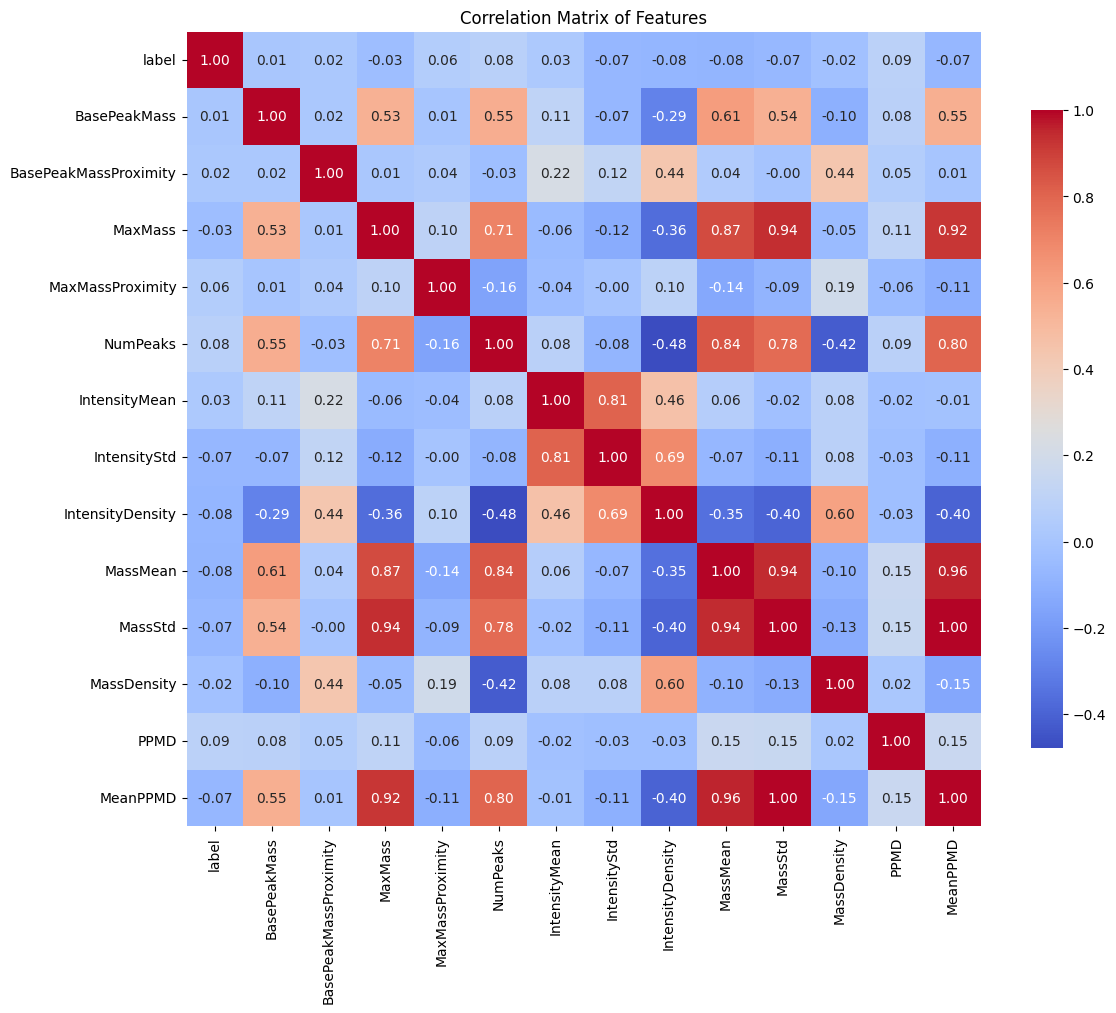

In [48]:
full_df.drop(columns=['Name'], inplace=True)
plt.figure(figsize=(12, 10))
sns.heatmap(full_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()


In [49]:
X = full_df.drop(columns=['label'])
y = full_df['label']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns)

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.80
to_drop = set()

for col in upper.columns:
    correlated_features = upper.index[upper[col] > threshold].tolist()
    for corr_feat in correlated_features:
        if importances[col] < importances[corr_feat]:
            to_drop.add(col)
        else:
            to_drop.add(corr_feat)

print(f"Variables removed taking into account importance and correlation (> {threshold}):", to_drop)

full_df= full_df.drop(columns=list(to_drop))

feature_columns= full_df.drop(columns=['label']).columns.tolist()
full_df.head()

Variables removed taking into account importance and correlation (> 0.8): {'MaxMass', 'MassStd', 'IntensityStd', 'NumPeaks', 'MeanPPMD'}


,label,BasePeakMass,BasePeakMassProximity,MaxMassProximity,IntensityMean,IntensityDensity,MassMean,MassDensity,PPMD
0,2,214.0,1.0,1.0,43.277969,7.812500,129.617188,2.023438,14.0
1,2,98.0,1.0,1.0,67.734815,7.407407,115.703704,1.607407,1.0
2,3,174.0,1.0,1.0,28.967470,12.048193,117.566265,3.180723,1.0
3,3,172.0,1.0,1.0,33.186306,9.009009,116.468468,1.954955,1.0
4,6,152.0,1.0,1.0,21.322148,6.704698,127.657718,1.604027,1.0


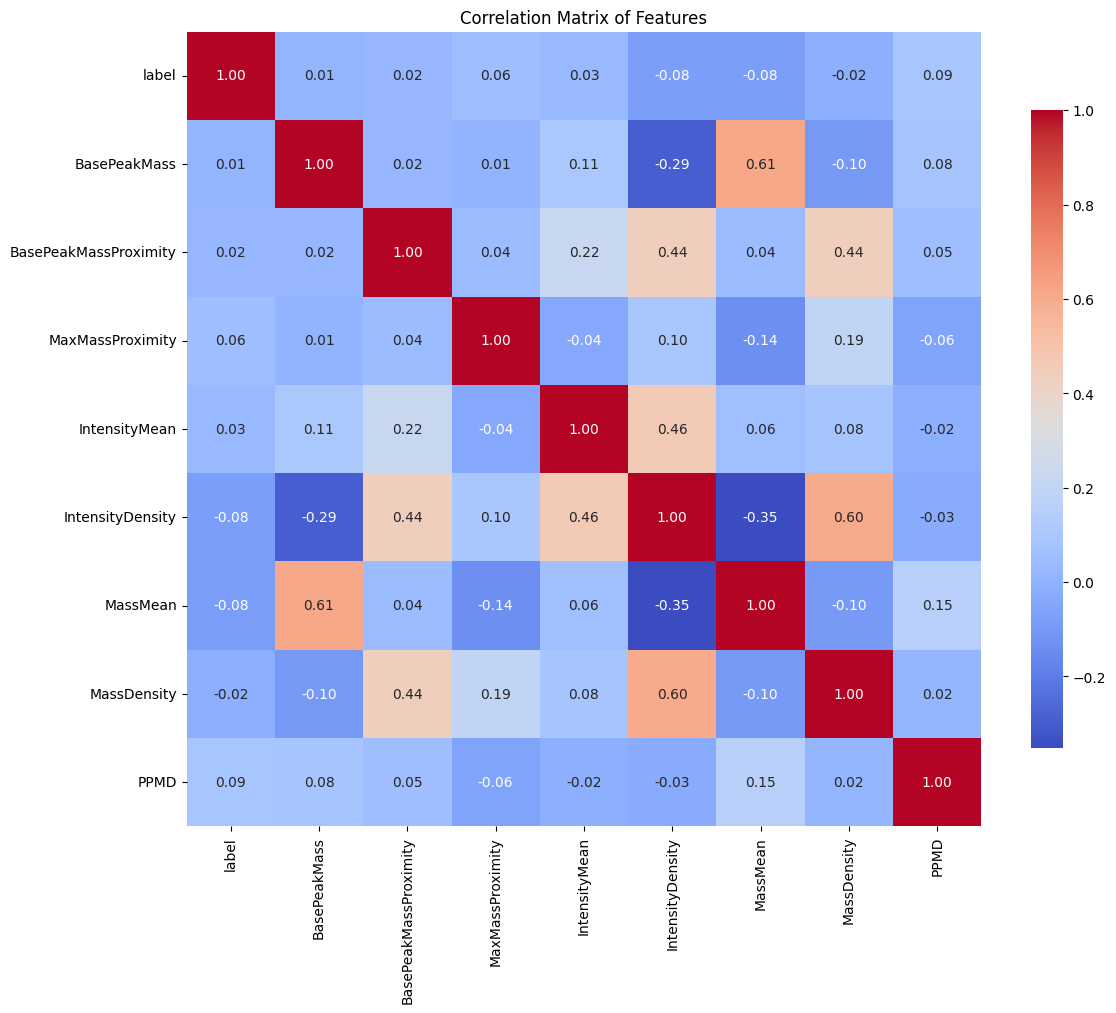

In [50]:
plt.figure(figsize=(12, 10))
sns.heatmap(full_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

The most relevant features for the model are preserved by avoiding removing random variables that may be important

# MODELLING


In [51]:
df = full_df.copy()  
Y = df['label']
X = df.drop(['label'], axis=1)
X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(f'The training set has {x_train.shape[0]} instances and {x_train.shape[1]} features.')
print(f'The test set has {x_test.shape[0]} instances and {x_test.shape[1]} features.')
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)
print(pd.Series(y_train).value_counts())

(3342, 8) (3342,)
The training set has 2673 instances and 8 features.
The test set has 669 instances and 8 features.
6    980
3    980
1    980
0    980
2    980
5    980
4    980
Name: count, dtype: int64


Classification Report
                          precision    recall  f1-score   support

     Cathinone analogues       0.72      0.78      0.75       124
   Cannabinoid analogues       0.51      0.62      0.56        60
Phenethylamine analogues       0.55      0.51      0.53        81
    Piperazine analogues       0.35      0.36      0.36        22
    Tryptamine analogues       0.39      0.56      0.46        32
      Fentanyl analogues       0.81      0.84      0.82       105
         Other compounds       0.75      0.64      0.69       245

                accuracy                           0.67       669
               macro avg       0.58      0.62      0.60       669
            weighted avg       0.68      0.67      0.67       669


Confusion Matrix


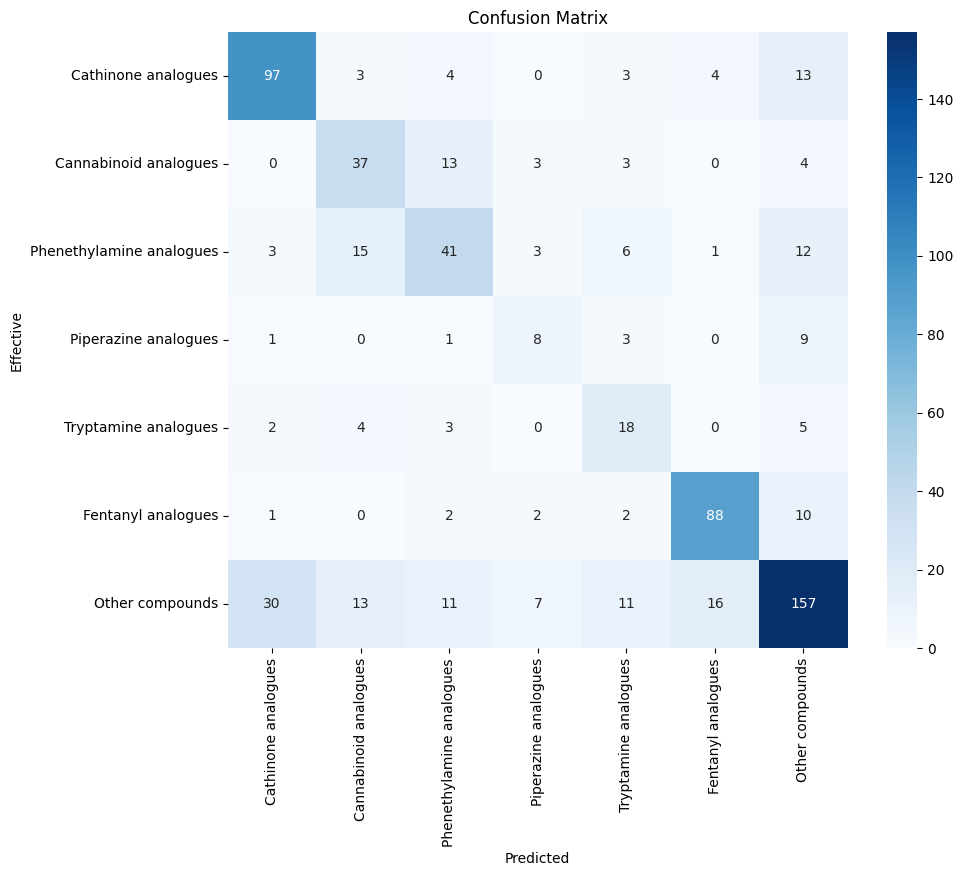


Cross-validation accuracy (4-fold): 0.85 ± 0.03


In [52]:
clf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print("Classification Report")
class_labels = [legends[i] for i in clf.classes_]
print(classification_report(y_test, y_pred, target_names=class_labels))
print("\nConfusion Matrix")
confusion_matrix_result = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()    

scores = cross_val_score(clf, x_train, y_train, cv=4)
print(f"\nCross-validation accuracy (4-fold): {scores.mean():.2f} ± {scores.std():.2f}")

In [53]:
joblib.dump(clf, 'model/balanced_random_forest_brf.pkl')

['model/balanced_random_forest_brf.pkl']

C:\Users\marco\AppData\Local\Temp\ipykernel_23712\4113250139.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


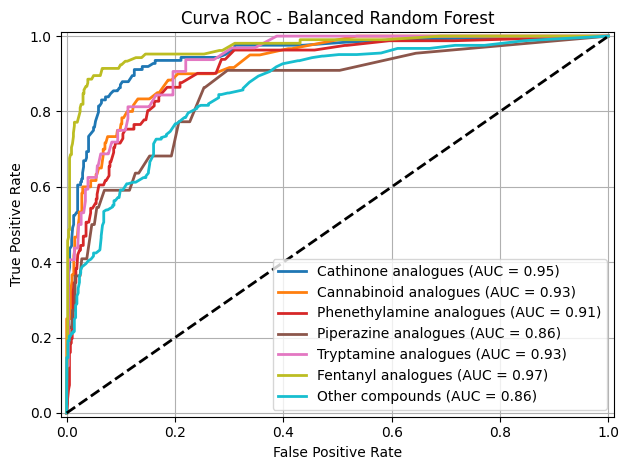

In [54]:
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(x_test)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.


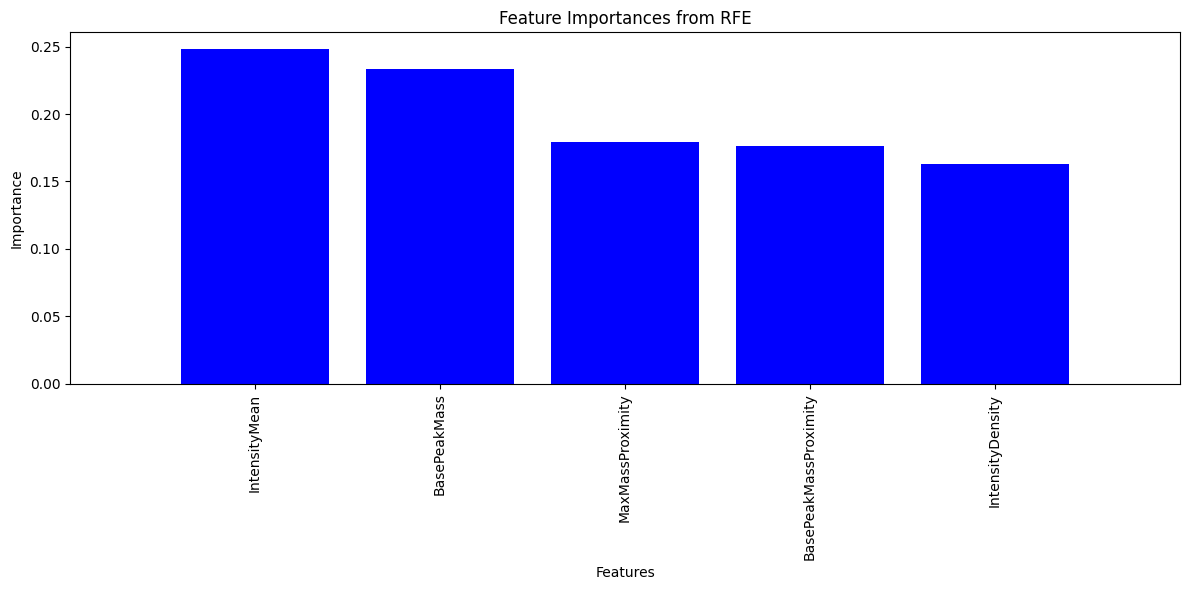

In [55]:
rfe_base_clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rfe = RFE(rfe_base_clf, n_features_to_select=5, verbose=1)
clf_rfe.fit(x_train, y_train)
importances = clf_rfe.estimator_.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances from RFE")
plt.bar(range(len(importances)), importances[indices], color='b', align='center')
plt.xticks(range(len(importances)), [feature_columns[i] for i in indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Selected Features: ['BasePeakMass' 'IntensityMean' 'IntensityDensity' 'MassMean'
 'MassDensity']
Classification Report after RFE
                          precision    recall  f1-score   support

     Cathinone analogues       0.70      0.77      0.74       124
   Cannabinoid analogues       0.57      0.62      0.59        60
Phenethylamine analogues       0.58      0.56      0.57        81
    Piperazine analogues       0.26      0.41      0.32        22
    Tryptamine analogues       0.38      0.53      0.44        32
      Fentanyl analogues       0.81      0.83      0.82       105
         Other compounds       0.73      0.60      0.66       245

                accuracy                           0.65       669
               macro avg       0.57      0.62      0.59       669
            weighted avg       0.67      0.65      0.66       669



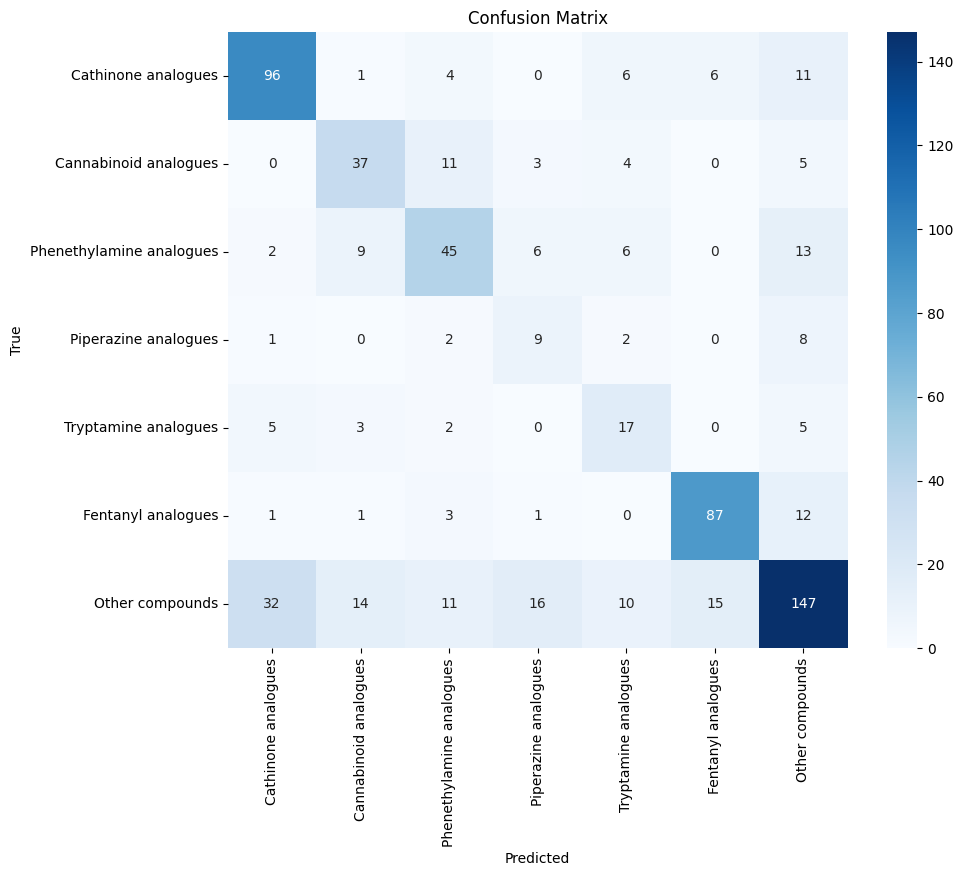


Cross-validation accuracy (4-fold) after RFE: 0.84 ± 0.01


In [56]:
selected_indices = clf_rfe.support_
selected_features = np.array(feature_columns)[selected_indices]
print("Selected Features:", selected_features)
if isinstance(x_train, pd.DataFrame):
    X_train_selected = x_train.loc[:, selected_features].values
    X_test_selected = x_test.loc[:, selected_features].values
else:
    X_train_selected = x_train[:, selected_indices]
    X_test_selected = x_test[:, selected_indices]

bdt_clf_rfe = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
bdt_clf_rfe.fit(X_train_selected, y_train)
y_pred_rfe = bdt_clf_rfe.predict(X_test_selected)
print("Classification Report after RFE")
print(classification_report(y_test, y_pred_rfe, target_names=class_labels))
confusion_matrix_result = confusion_matrix(y_test, y_pred_rfe)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
plt.show()
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
scores = cross_val_score(bdt_clf_rfe, X_train_selected, y_train, cv=cv)
print(f"\nCross-validation accuracy (4-fold) after RFE: {scores.mean():.2f} ± {scores.std():.2f}")

In [57]:
joblib.dump(bdt_clf_rfe, 'model/balanced_random_forest_rfe.pkl')

['model/balanced_random_forest_rfe.pkl']

C:\Users\marco\AppData\Local\Temp\ipykernel_23712\585756723.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


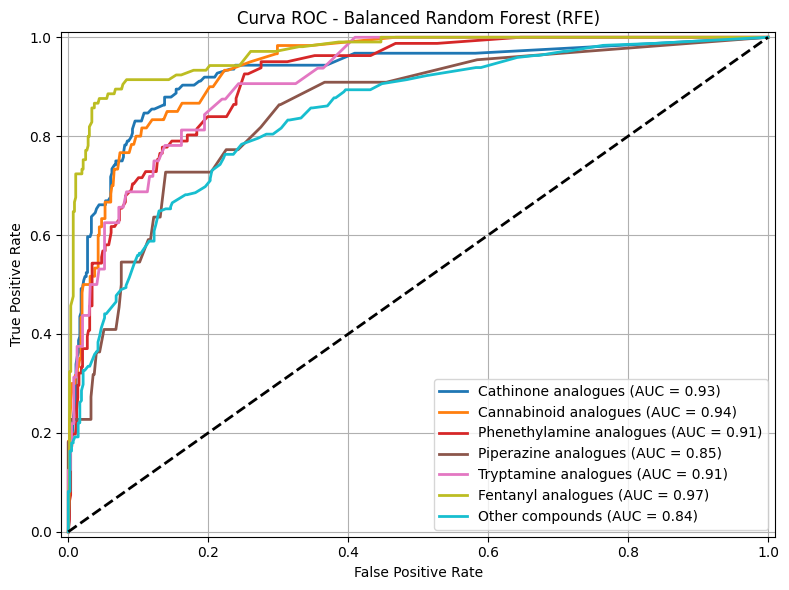

In [58]:
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score_rfe = bdt_clf_rfe.predict_proba(X_test_selected)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_rfe[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest (RFE)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Best parameters found:  {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 50, 'criterion': 'entropy'}
Best cross-validation score:  0.8335296449698634

Classification Report (Best Model)
                          precision    recall  f1-score   support

     Cathinone analogues       0.71      0.81      0.76       124
   Cannabinoid analogues       0.52      0.62      0.56        60
Phenethylamine analogues       0.58      0.53      0.55        81
    Piperazine analogues       0.22      0.27      0.24        22
    Tryptamine analogues       0.39      0.56      0.46        32
      Fentanyl analogues       0.82      0.85      0.84       105
         Other compounds       0.75      0.62      0.68       245

                accuracy                           0.67       669
               macro avg       0.57      0.61      0.59       669
            weighted avg       0.68      0.67      0.67       669


Confusion Matrix (Best Model)


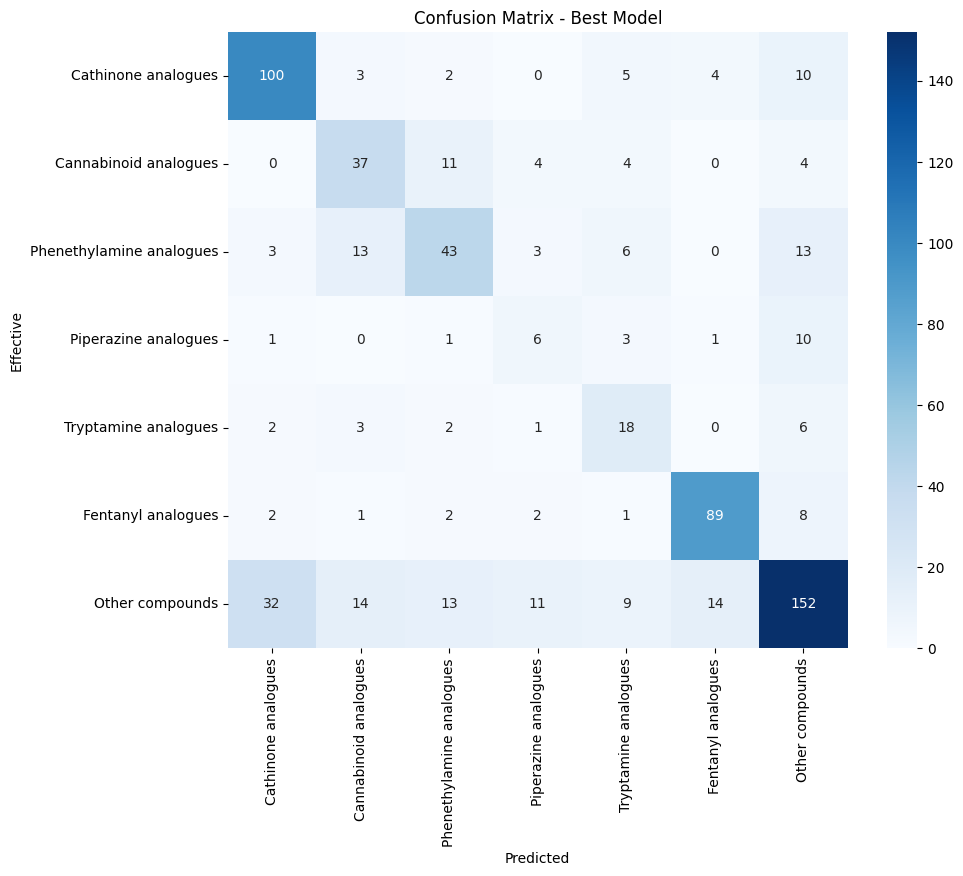


Cross-validation score (Best Model)
Cross-validation accuracy (4-fold): 0.48 ± 0.03


In [59]:
param_distributions = {
    'n_estimators': [10, 50, 100, 150],
    'max_depth': [None, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    estimator=bdt_clf_rfe,
    param_distributions=param_distributions,
    n_iter=20, 
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation score: ", random_search.best_score_)
best_clf = random_search.best_estimator_
y_pred_best = best_clf.predict(x_test)

print("\nClassification Report (Best Model)")
print(classification_report(y_test, y_pred_best, target_names=class_labels))

print("\nConfusion Matrix (Best Model)")

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()

print("\nCross-validation score (Best Model)")
scores_best = cross_val_score(best_clf, x_test, y_test, cv=4)
print(f"Cross-validation accuracy (4-fold): {scores_best.mean():.2f} ± {scores_best.std():.2f}")


Decision tree


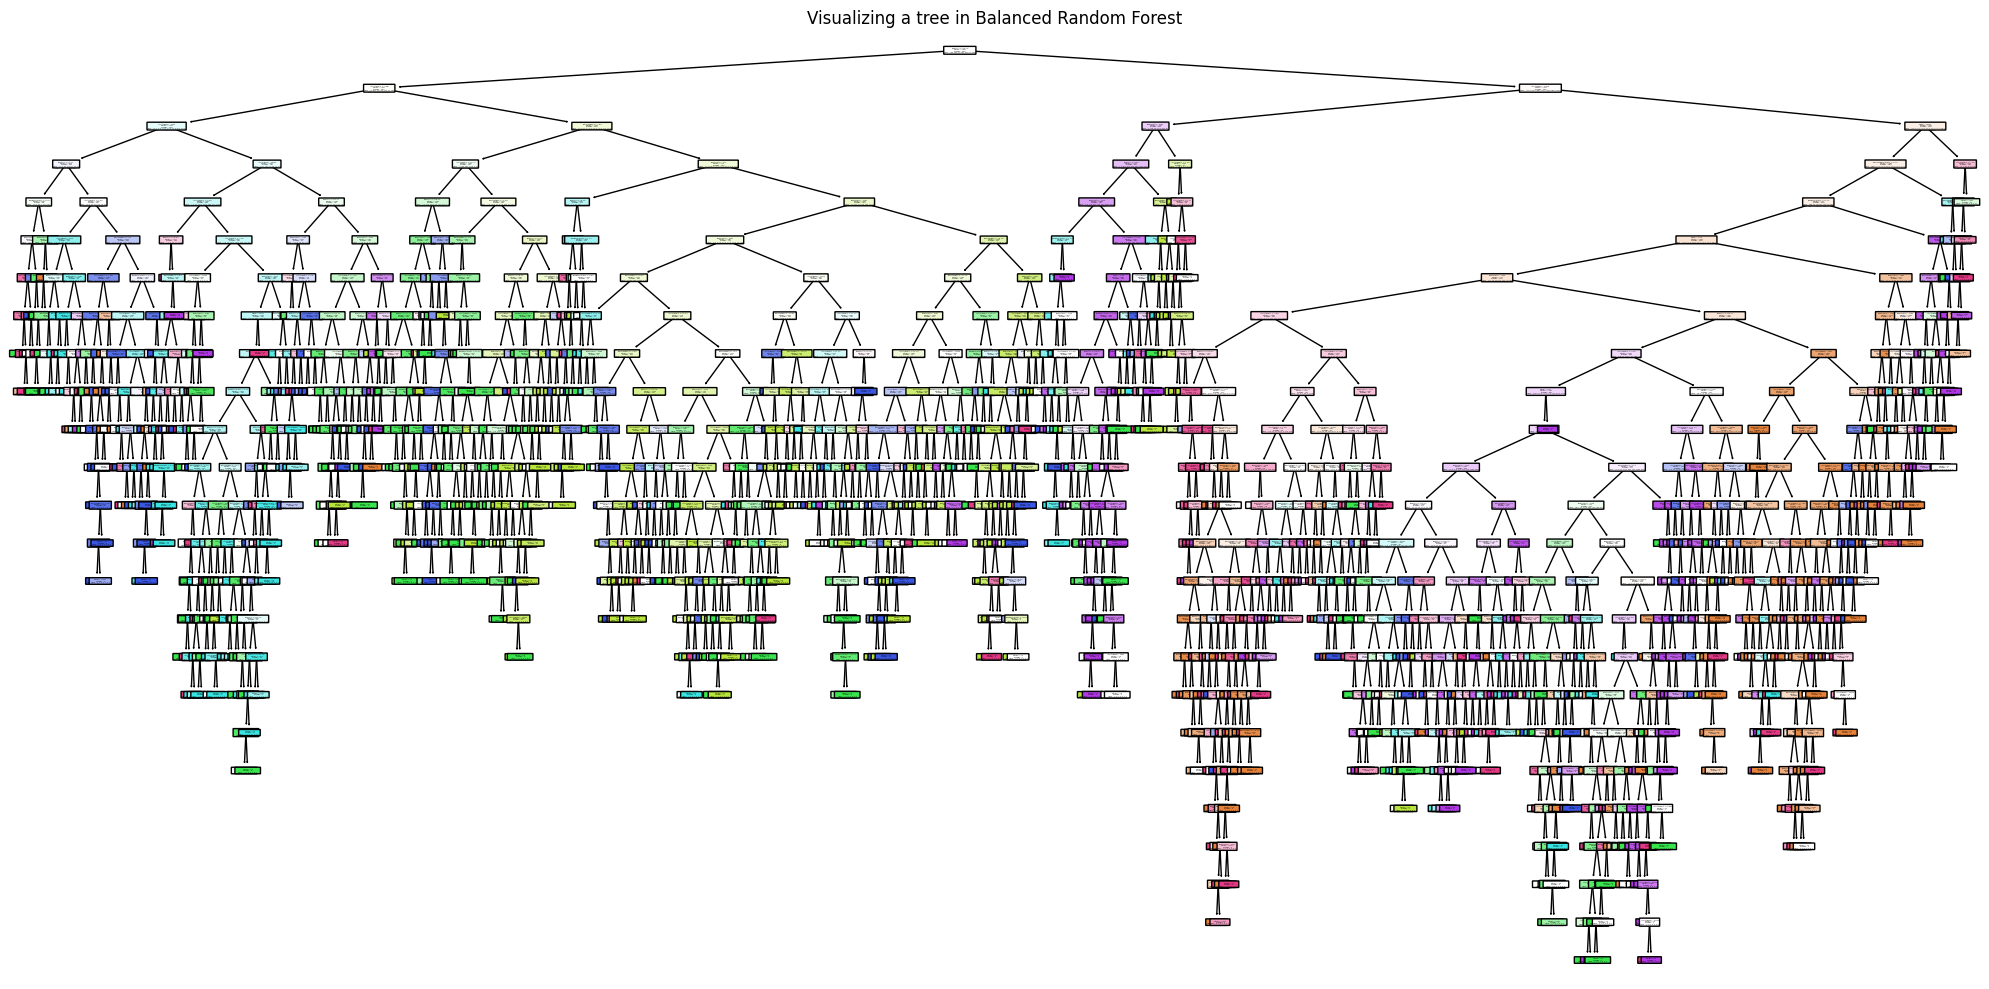


Average tree metrics
n_nodes      2080.32
max_depth      21.68
dtype: float64


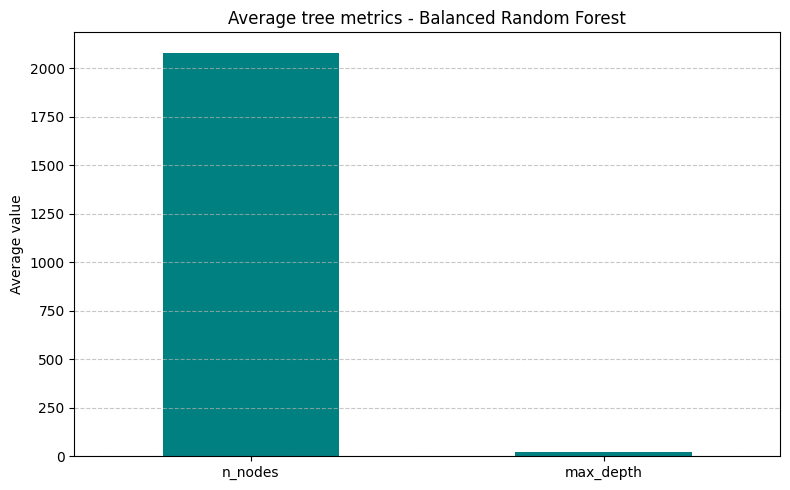

In [60]:
print("\nDecision tree")
plt.figure(figsize=(20, 10))
plot_tree(
    best_clf.estimators_[0],
    feature_names=feature_columns,
    class_names=[legends[i] for i in best_clf.classes_],
    filled=True,
    rounded=True,
)
plt.title("Visualizing a tree in Balanced Random Forest")
plt.tight_layout()
plt.show()

print("\nAverage tree metrics")
metrics = {
    'n_nodes': [est.tree_.node_count for est in best_clf.estimators_],
    'max_depth': [est.tree_.max_depth for est in best_clf.estimators_]
}
metrics_df = pd.DataFrame(metrics)
print(metrics_df.mean())
metrics_df.mean().plot(kind='bar', figsize=(8, 5), color='teal')
plt.title('Average tree metrics - Balanced Random Forest')
plt.ylabel('Average value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_23712\3432296515.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


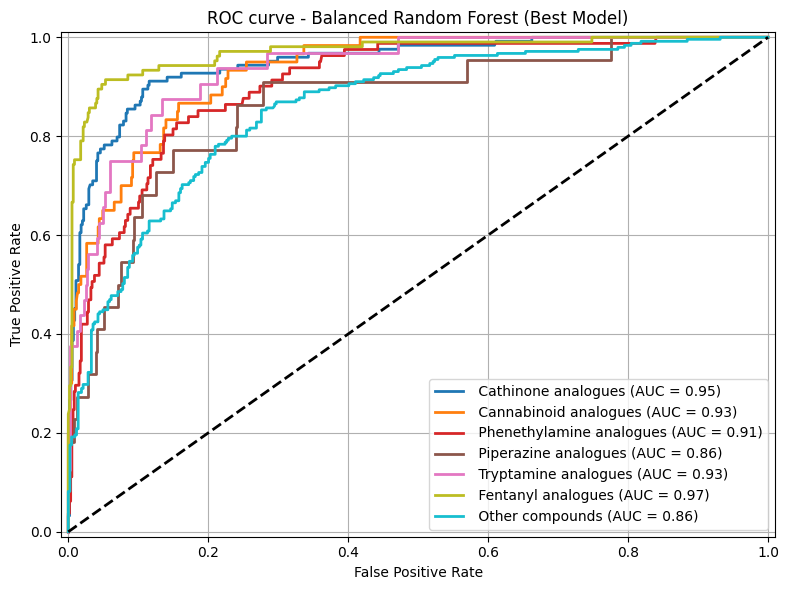

In [61]:
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_clf.predict_proba(x_test)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f" {class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve - Balanced Random Forest (Best Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
joblib.dump(best_clf, 'model/balanced_random_forest_brf_hmp.pkl')
x_test_brf = x_test.copy()


In [63]:
spectrum_dataset= nps_dataset.copy().drop(columns=['Name'])
print(f'The spectrum dataset has {spectrum_dataset.shape[0]} instances and {spectrum_dataset.shape[1]} features.')
spectrum_dataset.head()

The spectrum dataset has 3342 instances and 601 features.


,1,2,3,4,5,6,7,8,9,10,...,592,593,594,595,596,597,598,599,600,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6


In [64]:
model = keras.Sequential(name = 'dnn')
model.add(keras.Input(shape=(600,)))
model.add(layers.Dense(300, activation = 'relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(30, activation = 'relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(7, activation = 'softmax'))
print(model.summary())
plot_model(model, to_file="dnn_model_structure.png", show_shapes=True, show_layer_names=True, dpi=96,)

Model: "dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 300)            │       180,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         9,030 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,547 (740.42 KB)

 Trainable params: 189,547 (740.42 KB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.


In [65]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'],
)

Y = spectrum_dataset['label']
X = spectrum_dataset.drop(['label'], axis=1)
X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f'The training set has {x_train.shape[0]} instances and {x_train.shape[1]} features.')
print(f'The test set has {x_test.shape[0]} instances and {x_test.shape[1]} features.')
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print(pd.Series(y_train).value_counts())
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)
print(pd.Series(y_train).value_counts())

early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=5,            
    restore_best_weights=True 
)

history= model.fit(
    x_train, y_train,  
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop] 
)

(3342, 600) (3342,)
The training set has 2673 instances and 600 features.
The test set has 669 instances and 600 features.
6    970
0    507
5    430
2    314
1    237
4    126
3     89
Name: count, dtype: int64
6    970
2    970
3    970
5    970
0    970
1    970
4    970
Name: count, dtype: int64
Epoch 1/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5828 - loss: 1.2197 - val_accuracy: 0.2968 - val_loss: 1.8972
Epoch 2/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7404 - loss: 0.7713 - val_accuracy: 0.4190 - val_loss: 1.4124
Epoch 3/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7830 - loss: 0.6312 - val_accuracy: 0.5457 - val_loss: 1.0918
Epoch 4/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8194 - loss: 0.5467 - val_accuracy: 0.6944 - val_loss: 0.8523
Epoch 5/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8428 - loss: 0.4802 - val_accuracy: 0.6384 - val_loss: 0.8959
Epoch 6/50
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accur

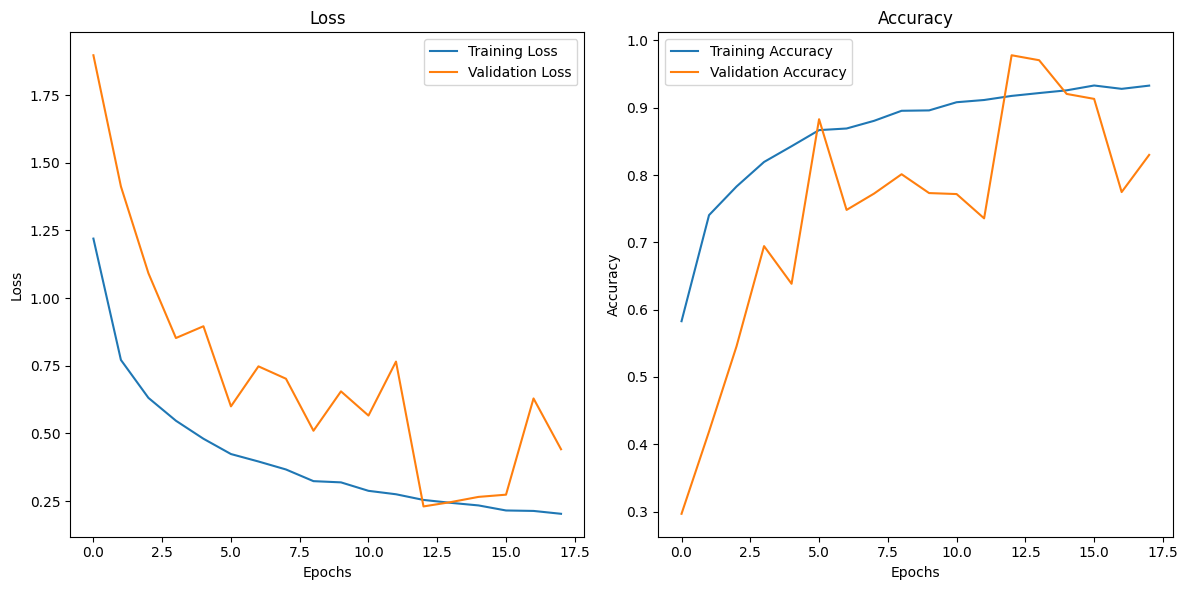

In [66]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Classification Report
                          precision    recall  f1-score   support

     Cathinone analogues       0.77      0.78      0.77       113
   Cannabinoid analogues       0.66      0.78      0.72        63
Phenethylamine analogues       0.66      0.67      0.66        88
    Piperazine analogues       0.52      0.68      0.59        22
    Tryptamine analogues       0.48      0.61      0.53        33
      Fentanyl analogues       0.85      0.79      0.82        95
         Other compounds       0.78      0.71      0.74       255

                accuracy                           0.73       669
               macro avg       0.67      0.72      0.69       669
            weighted avg       0.74      0.73      0.73       669


Confusion Matrix


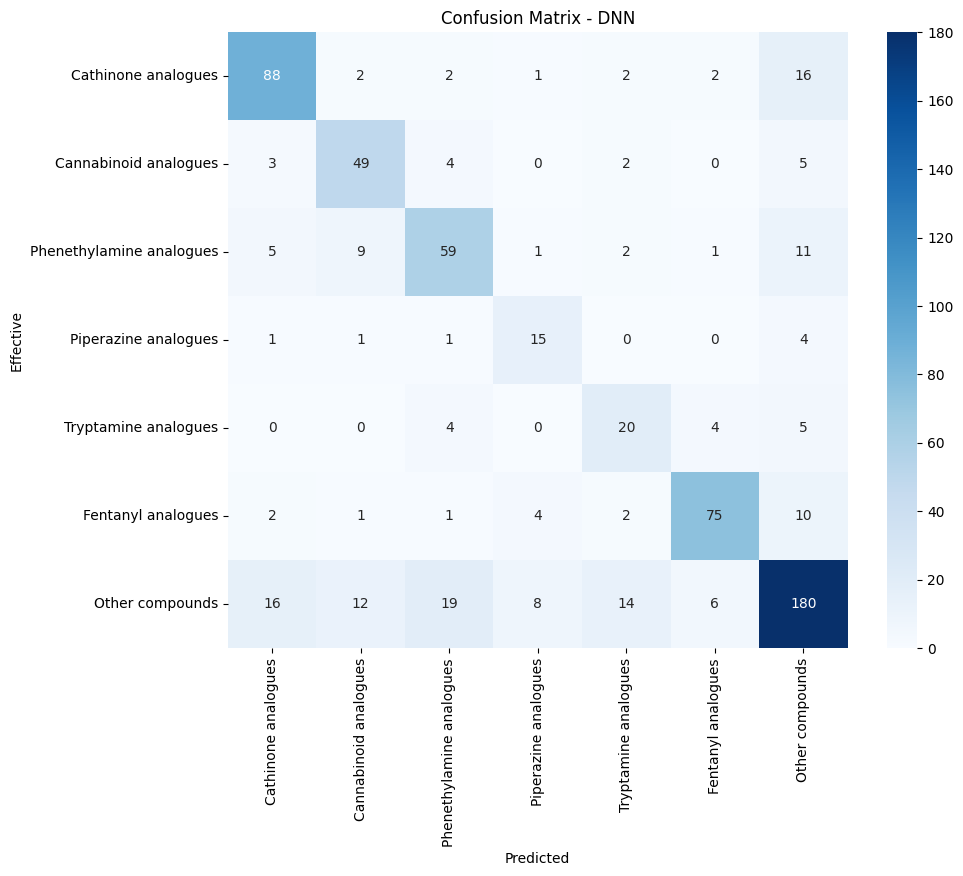

In [67]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Classification Report")
print(classification_report(y_test, y_pred_classes, target_names=class_labels))
print("\nConfusion Matrix")
confusion_matrix_result = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DNN')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


C:\Users\marco\AppData\Local\Temp\ipykernel_23712\4129286915.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


<Figure size 800x600 with 0 Axes>

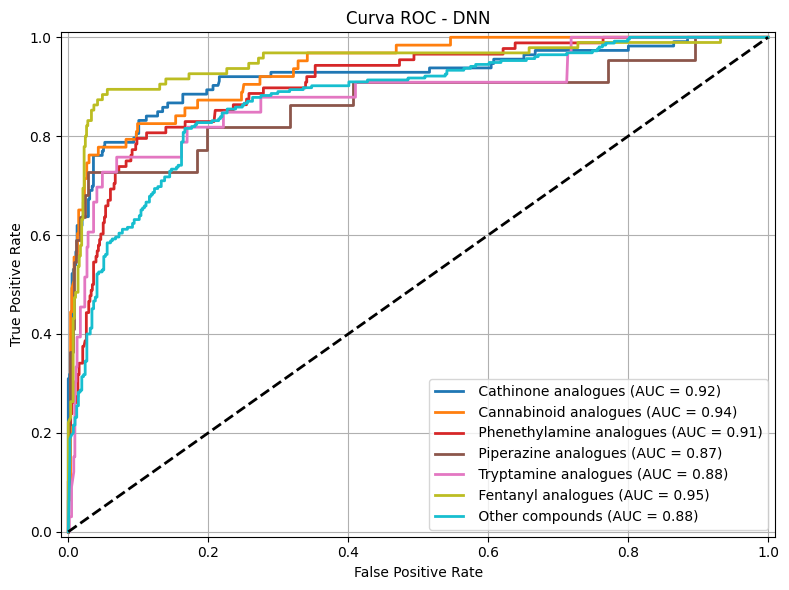

In [68]:
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model.predict(x_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(8, 6))
n_classes = len(classes)
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
                label=f" {class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - DNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
model.save('model/dnn_spectra_version.keras')
joblib.dump(scaler, "model/scale_dnn.pkl")

['model/scale_dnn.pkl']

# XGBOOST MODEL ANALYSIS

In [70]:
scaler_xgb = joblib.load("model/xgb_scaler.pkl")
xgb_model = XGBClassifier()
xgb_model.load_model("model/xgb_nps_model.json")
X_spectrum = spectrum_dataset.drop(columns=["label"]).values
Y_spectrum = spectrum_dataset["label"].values
x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(
    X_spectrum, Y_spectrum, test_size=0.2, random_state=42, stratify=Y_spectrum
)
x_test_s_scaled = scaler_xgb.transform(x_test_s)
y_pred_xgb = xgb_model.predict(x_test_s_scaled)


# 1) ACCURACY & REPORT

In [71]:
print(f"\nAccuracy XGBoost: {accuracy_score(y_test_s, y_pred_xgb):.4f}")
acc_xgb = accuracy_score(y_test_s, y_pred_xgb)
print("\nCLASSIFICATION REPORT XGBOOST")
print(classification_report(y_test_s, y_pred_xgb, target_names=class_labels))


Accuracy XGBoost: 0.9851

CLASSIFICATION REPORT XGBOOST
                          precision    recall  f1-score   support

     Cathinone analogues       0.99      0.98      0.99       124
   Cannabinoid analogues       1.00      0.97      0.98        60
Phenethylamine analogues       0.92      0.99      0.95        81
    Piperazine analogues       1.00      0.95      0.98        22
    Tryptamine analogues       1.00      0.97      0.98        32
      Fentanyl analogues       0.99      0.99      0.99       105
         Other compounds       1.00      0.99      0.99       245

                accuracy                           0.99       669
               macro avg       0.99      0.98      0.98       669
            weighted avg       0.99      0.99      0.99       669



# 2) CONFUSION MATRIX

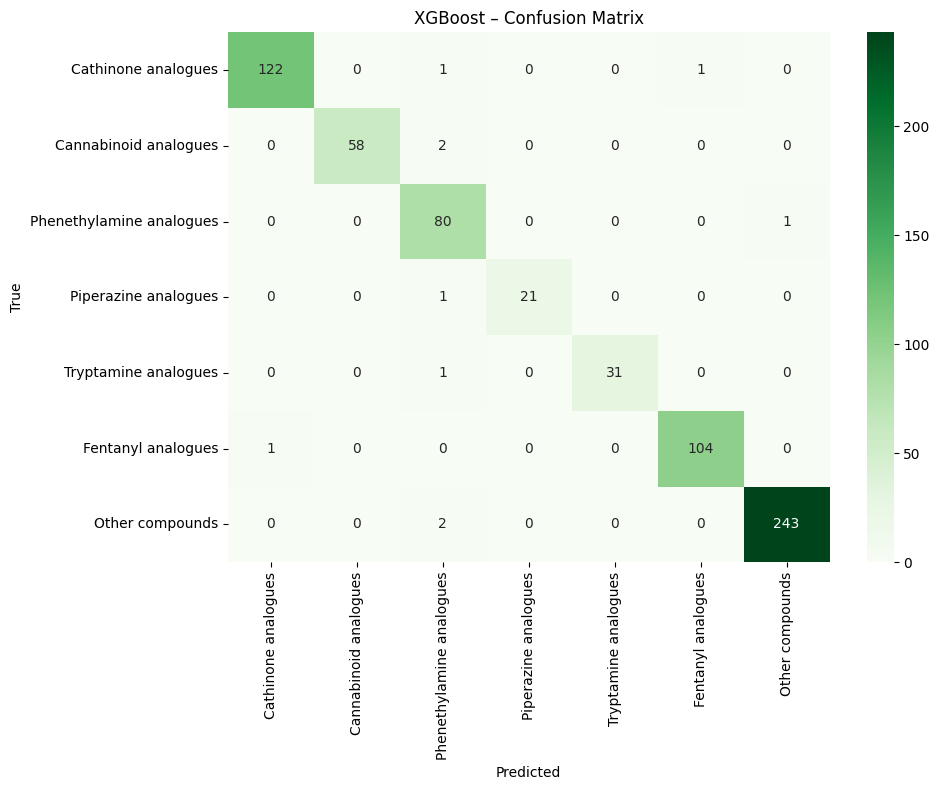

In [72]:
cm = confusion_matrix(y_test_s, y_pred_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("XGBoost – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 3) FEATURE IMPORTANCE

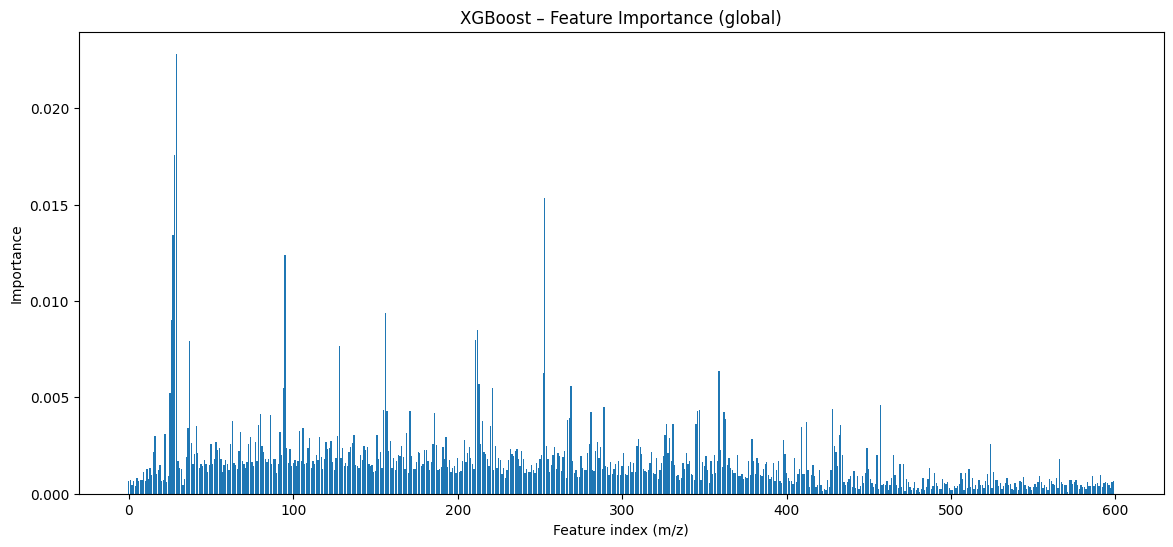

In [73]:
importances = xgb_model.feature_importances_
plt.figure(figsize=(14, 6))
plt.bar(range(len(importances)), importances)
plt.title("XGBoost – Feature Importance (global)")
plt.xlabel("Feature index (m/z)")
plt.ylabel("Importance")
plt.show()

# 4) ROC CURVE MULTICLASS

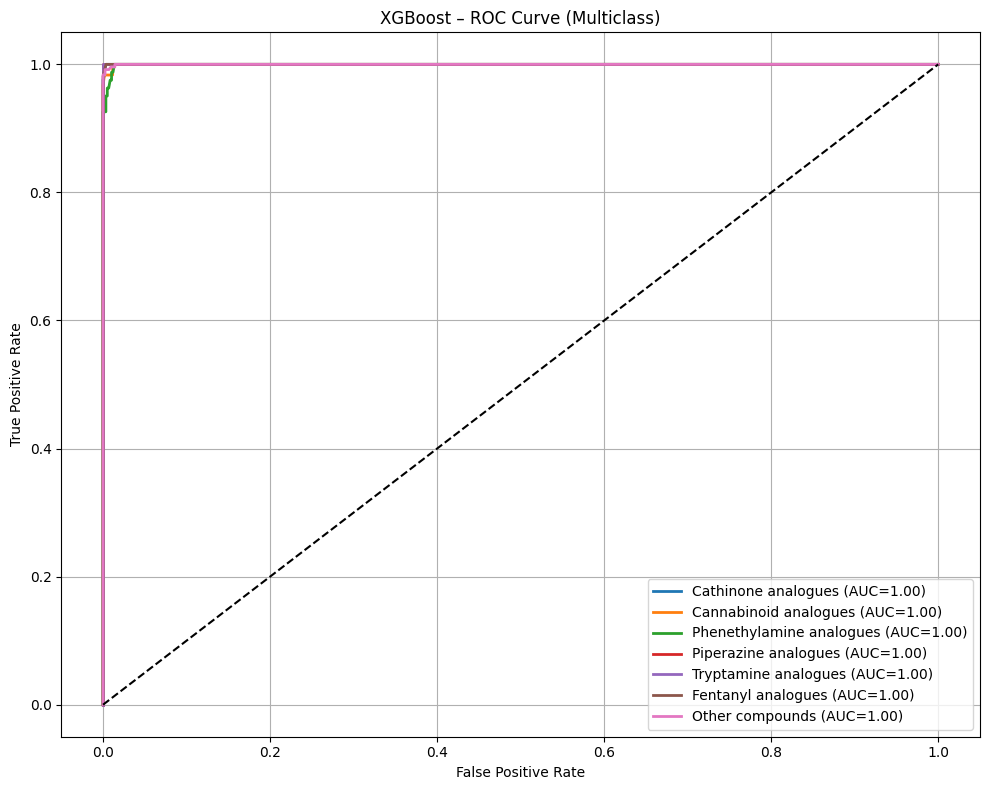

In [74]:
y_test_bin = label_binarize(y_test_s, classes=np.unique(Y_spectrum))
y_score = xgb_model.predict_proba(x_test_s_scaled)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = plt.colormaps.get_cmap("tab10")

for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], lw=2, color=colors(i),
             label=f"{class_labels[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost – ROC Curve (Multiclass)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) CROSS VALIDATION (solo training)

In [75]:
print("\nRunning Cross-Validation (5-fold)...")

x_train_scaled = scaler_xgb.transform(x_train_s)
cv_scores = cross_val_score(
    xgb_model, x_train_scaled, y_train_s,
    cv=5, scoring='accuracy'
)

print(f"Cross-val mean accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Running Cross-Validation (5-fold)...
Cross-val mean accuracy: 0.8466 ± 0.0089


# COMPARISON WITH CLAUDIO'S ORIGINAL MODELS

In [76]:
brf_original = joblib.load("model/Claudio/balanced_random_forest_brf.pkl")

if hasattr(brf_original, "n_features_in_"):
    n_features_old = brf_original.n_features_in_
    print(f"[INFO] The original BRF model expects {n_features_old} features, I use the first ones {n_features_old}.")
    x_test_brf_old = x_test[:, :n_features_old]
else:
    x_test_brf_old = x_test

[INFO] The original BRF model expects 9 features, I use the first ones 9.


c:\Users\marco\Desktop\Marco\Universita\Magistrale\Traineeship\Progetto\Pention-System\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(




BalancedRandomForest comparison: new vs. original model (Claudio)

Accuracy (New model): 0.1943
Accuracy ((Claudio's model)): 0.1315


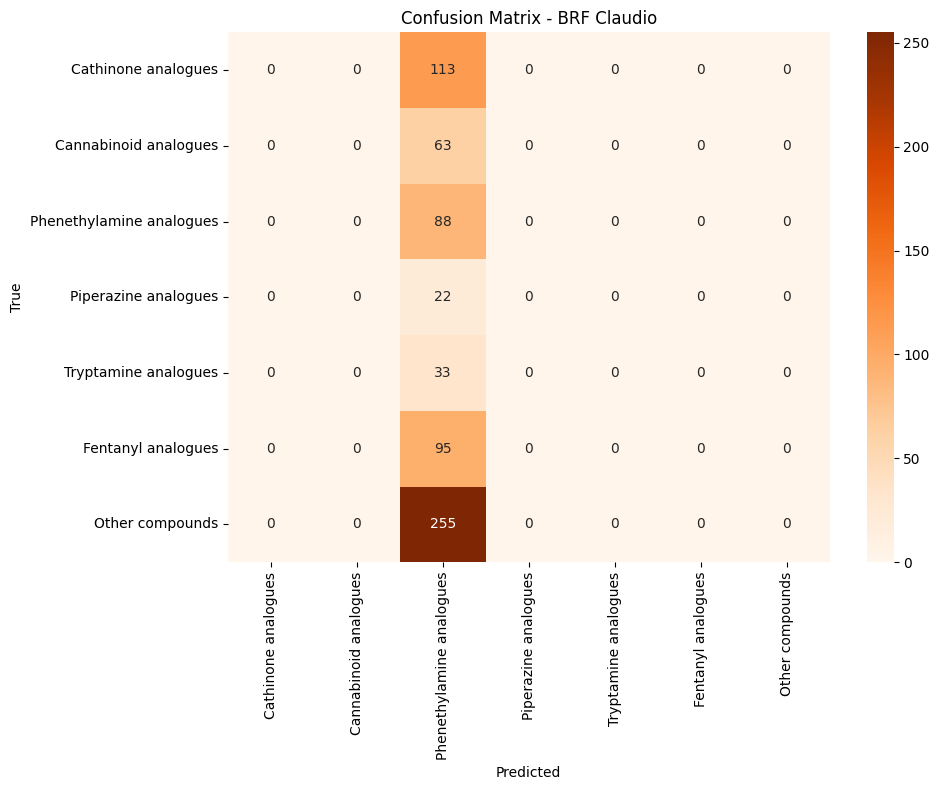



DNN comparison: new vs. original model (Claudio)
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Accuracy (New DNN): 0.7265
Accuracy (Claudio's model): 0.3483

Classification Report DNN (Claudio's model)
                          precision    recall  f1-score   support

     Cathinone analogues       0.01      0.01      0.01       113
   Cannabinoid analogues       0.03      0.05      0.04        63
Phenethylamine analogues       0.44      0.39      0.41        88
    Piperazine analogues       0.14      0.82      0.24        22
    Tryptamine analogues       0.34      0.52      0.41        33
      Fentanyl analogues       0.52      0.52      0.52        95
         Other compounds       0.76      0.44      0.55       255

                accuracy                           0.35       669
               macro avg       0.32      0.39      0.31       669
            weighted avg       0.45      0.35      0.37       669



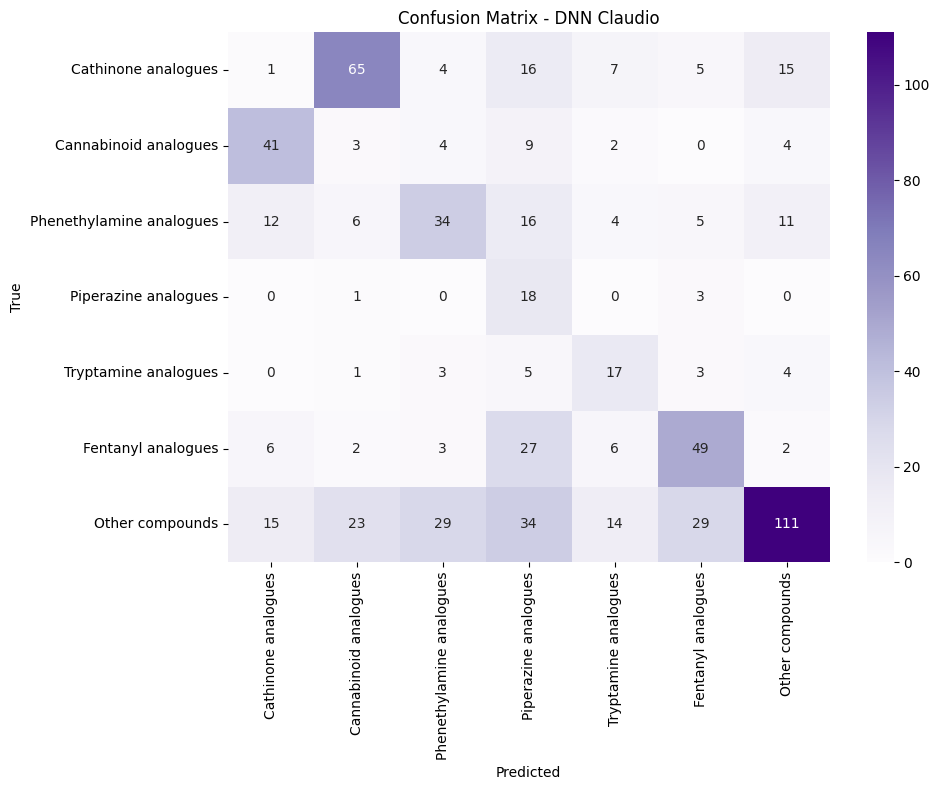

In [77]:
print("\n\nBalancedRandomForest comparison: new vs. original model (Claudio)")
y_pred_new = best_clf.predict(x_test_brf)
y_pred_old = brf_original.predict(x_test_brf_old)
acc_new = accuracy_score(y_test, y_pred_new)
acc_old = accuracy_score(y_test, y_pred_old)
print(f"\nAccuracy (New model): {acc_new:.4f}")
print(f"Accuracy ((Claudio's model)): {acc_old:.4f}")
confusion_matrix_result = confusion_matrix(y_test, y_pred_old)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - BRF Claudio')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
plt.tight_layout()
plt.show()
print("\n\nDNN comparison: new vs. original model (Claudio)")
dnn_original = load_model("model/Claudio/dnn_spectra_version.keras")
y_pred_dnn_new = model.predict(x_test)
y_pred_dnn_old = dnn_original.predict(x_test)
y_classes_new = np.argmax(y_pred_dnn_new, axis=1)
y_classes_old = np.argmax(y_pred_dnn_old, axis=1)
acc_new_dnn = accuracy_score(y_test, y_classes_new)
acc_old_dnn = accuracy_score(y_test, y_classes_old)
print(f"\nAccuracy (New DNN): {acc_new_dnn:.4f}")
print(f"Accuracy (Claudio's model): {acc_old_dnn:.4f}")
print("\nClassification Report DNN (Claudio's model)")
print(classification_report(y_test, y_classes_old, target_names=class_labels))
confusion_matrix_result = confusion_matrix(y_test, y_classes_old)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DNN Claudio')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
plt.tight_layout()
plt.show()

# FINAL COMPARISON BETWEEN THE THREE MODELS

In [78]:
print("FINAL MODEL COMPARISON")

print(f"\nAccuracy BRF (Claudio): {acc_old:.4f}")
print(f"Accuracy BRF new (Best Model): {acc_new:.4f}")
print(f"Final XGBoost Accuracy (PENTION-M): {acc_xgb:.4f}")

print("\nBEST MODEL:", 
      ["BRF Claudio", "BRF new", "XGBoost"][np.argmax([
          acc_old,
          acc_new,
          acc_xgb
      ])])

FINAL MODEL COMPARISON

Accuracy BRF (Claudio): 0.1315
Accuracy BRF new (Best Model): 0.1943
Final XGBoost Accuracy (PENTION-M): 0.9851

BEST MODEL: XGBoost
